In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.datasets import eegbci
subjects = [s for s in range(1, 81)] 
imagined_files = []

for s in subjects:
        img = eegbci.load_data(s, [4, 8, 12], path="/Users/navyers/Desktop/Physionet")
        imagined_files.extend(img)
print(f"Imagined files: {len(imagined_files)}")

IMAGINED_RUNS = [4, 8, 12]  # Corresponding to runs 4, 8, and 12 for imagined motor imagery tasks
EXCLUDE_CHANNELS = ['Fp1', 'Fp2', 'Fpz', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8'] 



/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imagined files: 240


Mismatched Sampling Rates (Not 160 Hz): []
Corrupt/Missing Task Labels:          []
Suggested Global BAD_SUBJECTS Array:   []

Visualizations for first 3 subjects...

--- Displaying Plots for Subject S001 ---
Using matplotlib as 2D backend.


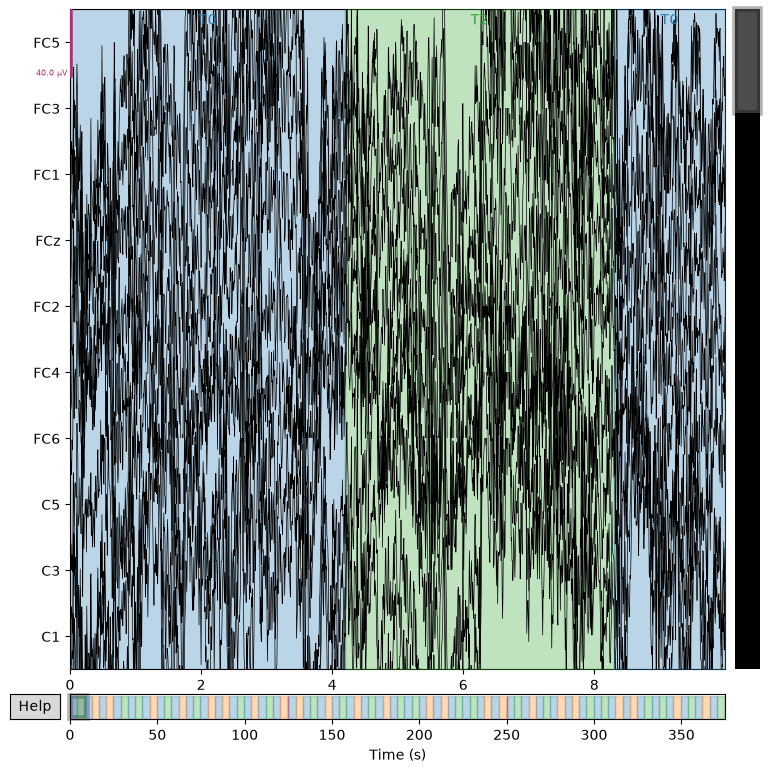

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/var/folders/g6/mg7_2zrx7xx2ys84v_s9_ysr0000gn/T/ipykernel_24752/2846134349.py:54: RuntimeWarning: The legacy plot_psd() method got an unexpected keyword argument 'axes', which is a parameter of Spectrum.plot(). Try rewriting as object.compute_psd(...).plot(..., axes=<whatever>).
  raw.plot_psd(fmax=80, axes=ax, show=False)
/var/folders/g6/mg7_2zrx7xx2ys84v_s9_ysr0000gn/T/ipykernel_24752/2846134349.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


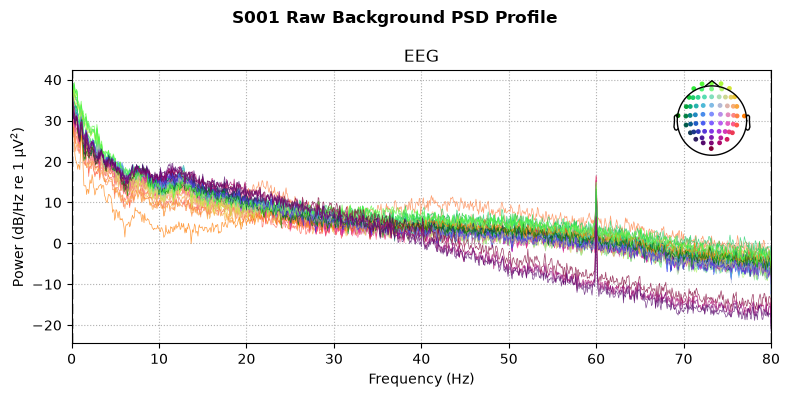


--- Displaying Plots for Subject S002 ---


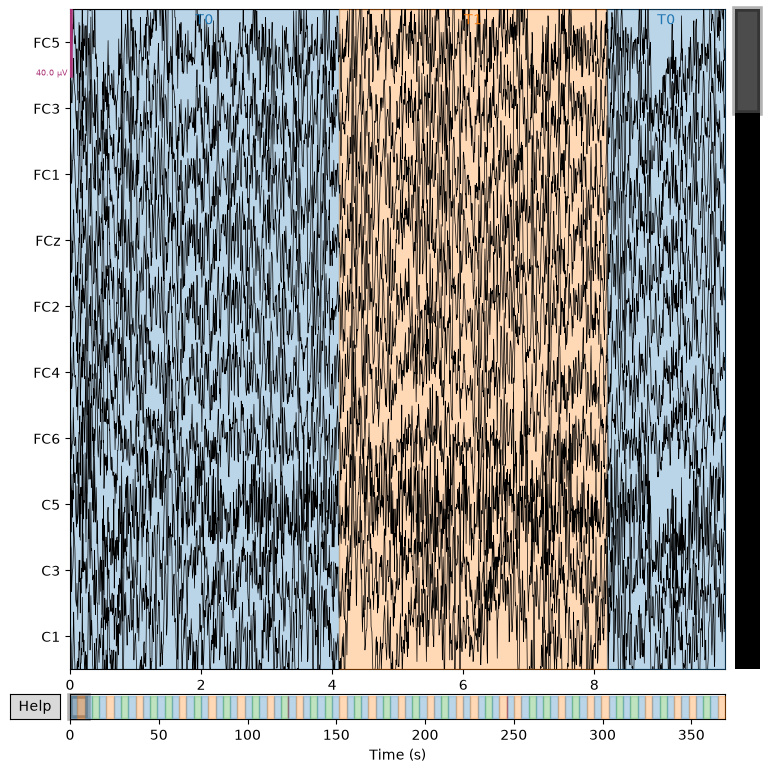

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/var/folders/g6/mg7_2zrx7xx2ys84v_s9_ysr0000gn/T/ipykernel_24752/2846134349.py:54: RuntimeWarning: The legacy plot_psd() method got an unexpected keyword argument 'axes', which is a parameter of Spectrum.plot(). Try rewriting as object.compute_psd(...).plot(..., axes=<whatever>).
  raw.plot_psd(fmax=80, axes=ax, show=False)
/var/folders/g6/mg7_2zrx7xx2ys84v_s9_ysr0000gn/T/ipykernel_24752/2846134349.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


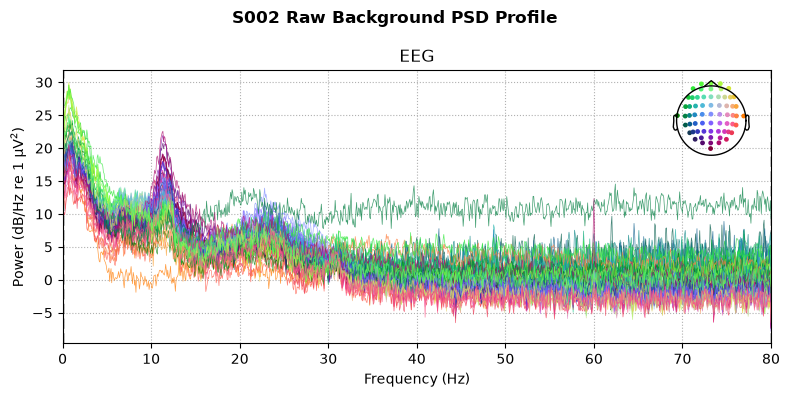


--- Displaying Plots for Subject S003 ---


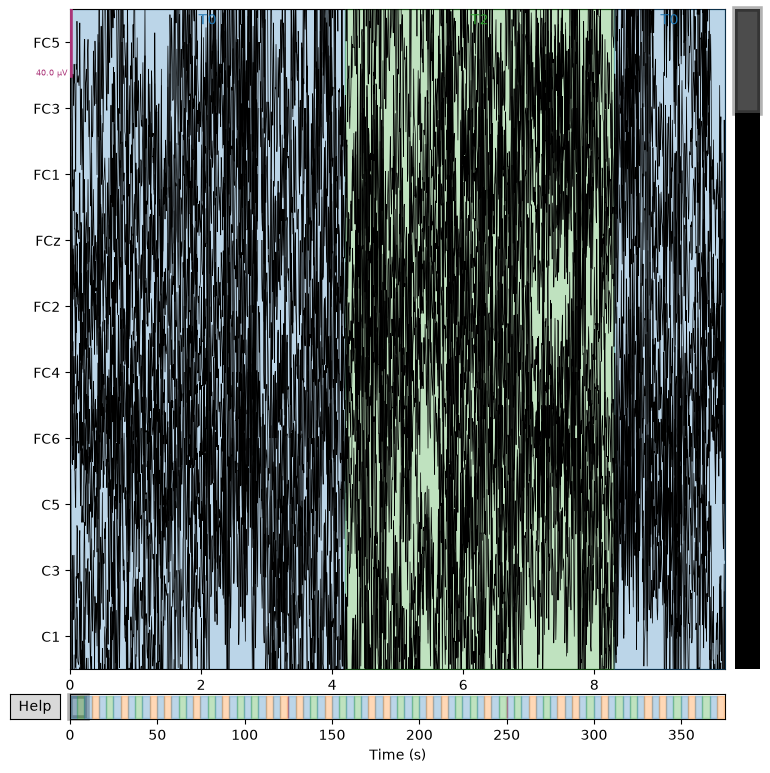

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/var/folders/g6/mg7_2zrx7xx2ys84v_s9_ysr0000gn/T/ipykernel_24752/2846134349.py:54: RuntimeWarning: The legacy plot_psd() method got an unexpected keyword argument 'axes', which is a parameter of Spectrum.plot(). Try rewriting as object.compute_psd(...).plot(..., axes=<whatever>).
  raw.plot_psd(fmax=80, axes=ax, show=False)
/var/folders/g6/mg7_2zrx7xx2ys84v_s9_ysr0000gn/T/ipykernel_24752/2846134349.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


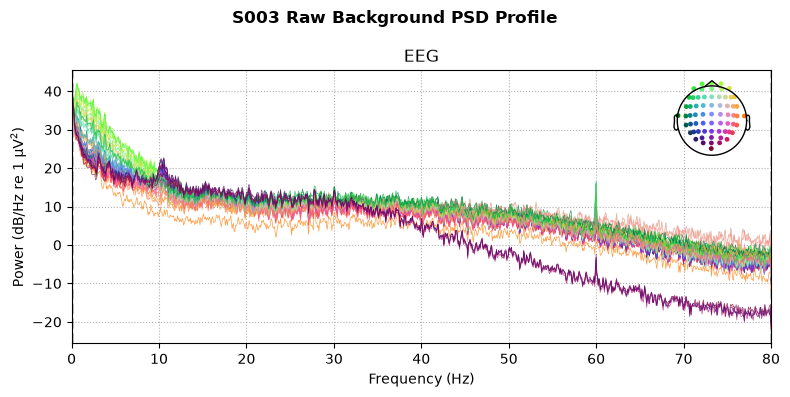

In [2]:
from mne.io import read_raw_edf

def load_subject(subject, runs):
    """Loads and concatenates runs, standardizing channel names to 10-10 system."""
    paths = eegbci.load_data(subject, runs, path="/Users/navyers/Desktop/Physionet")
    raws = [read_raw_edf(p, preload=True, verbose=False) for p in paths]
    raw = mne.concatenate_raws(raws)
    eegbci.standardize(raw)
    raw.set_montage(mne.channels.make_standard_montage('standard_1005'), on_missing='warn')
    return raw

def audit_all_subjects(runs=IMAGINED_RUNS):
    """
    Looks through ALL 80 subjects using metadata headers (preload=False).
    Identifies sampling rate mismatches and annotations.
    """
    
    mismatched_sfreq_subjects = []
    corrupt_annotation_subjects = []
    
    for s in range(1, 81):
            # Load only the first run of the session to check headers 
            paths = eegbci.load_data(s, [runs[0]], path="/Users/navyers/Desktop/Physionet")
            raw_check = read_raw_edf(paths[0], preload=False, verbose=False)
            
            sfreq = raw_check.info['sfreq']
            unique_annots = list(np.unique(raw_check.annotations.description))
            
            is_sfreq_bad = (sfreq != 160.0)
            is_annot_bad = ('T1' not in unique_annots or 'T2' not in unique_annots)
            
            if is_sfreq_bad or is_annot_bad:
                print(f"Subject S{s:03d}: sfreq = {sfreq} Hz | Annotations = {unique_annots}")
                if is_sfreq_bad:
                    print(f"  Sampling frequency deviates from 160.0 Hz baseline.")
                    mismatched_sfreq_subjects.append(s)
                if is_annot_bad:
                    print(f"  Missing stimulus labels ('T1'/'T2').")
                    corrupt_annotation_subjects.append(s)
                print("-" * 65)
            
    print(f"Mismatched Sampling Rates (Not 160 Hz): {mismatched_sfreq_subjects}")
    print(f"Corrupt/Missing Task Labels:          {corrupt_annotation_subjects}")
    print(f"Suggested Global BAD_SUBJECTS Array:   {list(set(mismatched_sfreq_subjects + corrupt_annotation_subjects))}")
    print("="*60 + "\n")

def check_subject(subject, runs):
    """Displays raw signal plot and Power Spectral Density without redundant text prints."""
    raw = load_subject(subject, runs)
    
    raw.plot(duration=10, n_channels=10, title=f"S{subject:03d} Raw EEG Signal Traces")
    plt.show()
    fig, ax = plt.subplots(figsize=(8, 4))
    raw.plot_psd(fmax=80, axes=ax, show=False)
    plt.suptitle(f"S{subject:03d} Raw Background PSD Profile", fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return raw

audit_all_subjects()

print("Visualizations for first 3 subjects...")
for s in [1, 2, 3]:
    print(f"\n--- Displaying Plots for Subject S{s:03d} ---")
    _ = check_subject(s, IMAGINED_RUNS)


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/var/folders/g6/mg7_2zrx7xx2ys84v_s9_ysr0000gn/T/ipykernel_24752/2493195091.py:16: RuntimeWarning: The legacy plot_psd() method got an unexpected keyword argument 'axes', which is a parameter of Spectrum.plot(). Try rewriting as object.compute_psd(...).plot(..., axes=<whatever>).
  raw_s1.plot_psd(fmax=80, axes=axes[0], show=False)
/var/folders/g6/mg7_2zrx7xx2ys84v_s9_ysr0000gn/T/ipykernel_24752/2493195091.py:18: RuntimeWarning: The legacy plot_psd() method got an unexpected keyword argument 'axes', which is a parameter of Spectrum.plot(). Try rewriting as object.compute_psd(...).plot(..., axes=<whatever>).
  raw_filt.plot_psd(fmax=80, axes=axes[1], show=False)
/var/folders/g6/mg7_2zrx7xx2ys84v_s9_ysr0000gn/T/ipykernel_24752/2493195091.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


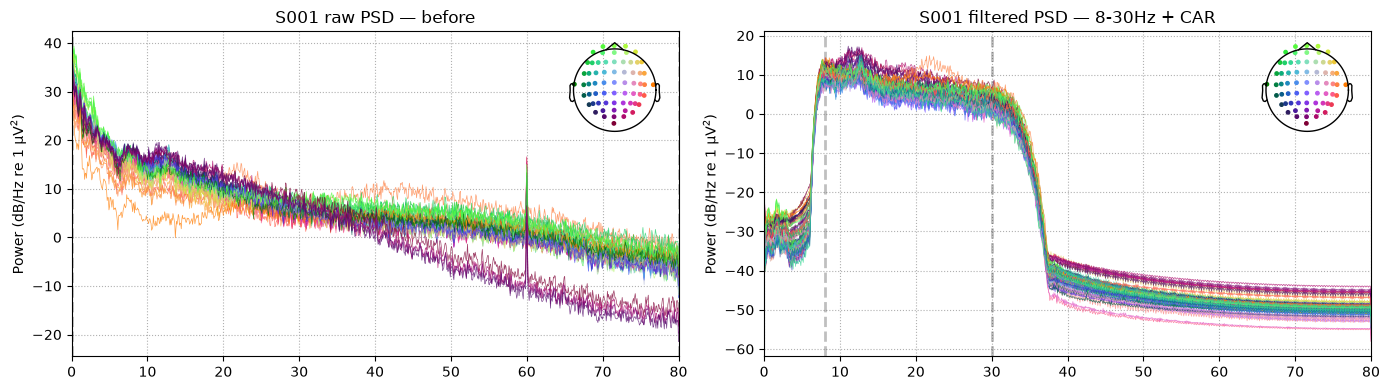

In [9]:
# 1. Reload Subject 001's data
raw_s1 = load_subject(subject=1, runs=IMAGINED_RUNS)

# copy first so can compare filtered + CAR to raw 
raw_filt = raw_s1.copy()

# bandpass 8-30 Hz — isolates mu (8-12 Hz) and beta (13-30 Hz)
# ERD during motor imagery lives entirely within this band
raw_filt.filter(8., 30., method='fir', verbose=False)

# common average reference 
raw_filt.set_eeg_reference('average', verbose=False)

# plot PSD before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
raw_s1.plot_psd(fmax=80, axes=axes[0], show=False)
axes[0].set_title("S001 raw PSD — before")
raw_filt.plot_psd(fmax=80, axes=axes[1], show=False)
axes[1].set_title("S001 filtered PSD — 8-30Hz + CAR")
plt.tight_layout()
plt.show()



In [4]:
# verify time-windowing before running full preprocessing 
# confirms epoch t=0 actually lands on the annotation onset, and that the
# 0.5-2.5s task window used downstream selects the samples we think it does


raw_check = load_subject(1, IMAGINED_RUNS)
events, eid = mne.events_from_annotations(raw_check, verbose=False)

# print the first few T1/T2 onsets directly from annotations, in seconds
annotations = raw_check.annotations
t1_t2_mask = np.isin(annotations.description, ['T1', 'T2'])
print("First 5 T1/T2 annotation onsets (raw recording time, seconds):")
for onset, desc in list(zip(annotations.onset[t1_t2_mask], annotations.description[t1_t2_mask]))[:5]:
    print(f"  {desc} at t={onset:.2f}s")

epochs_check = mne.Epochs(
    raw_check, events, event_id={'left': eid['T1'], 'right': eid['T2']},
    tmin=-1.0, tmax=2.5, baseline=None, preload=True, verbose=False
)

print(f"\nEpochs.times range: [{epochs_check.times[0]:.3f}, {epochs_check.times[-1]:.3f}]")
print(f"Expected: [-1.000, 2.500]")
print(f"n_times: {len(epochs_check.times)} (expected {int((2.5 - -1.0) * raw_check.info['sfreq']) + 1})")

first_event_sample = events[np.isin(events[:, 2], [eid['T1'], eid['T2']])][0, 0]
first_event_time_s = first_event_sample / raw_check.info['sfreq']
print(f"\nFirst T1/T2 event: sample {first_event_sample}, time {first_event_time_s:.3f}s")

ch_idx = raw_check.ch_names.index('C3')
raw_data, _ = raw_check[ch_idx, first_event_sample]
epoch_data_at_t0 = epochs_check.get_data()[0, ch_idx, np.argmin(np.abs(epochs_check.times))]

print(f"Raw signal at C3, onset sample: {raw_data[0][0]*1e6:.4f} μV")
print(f"Epoch[0] signal at C3, t≈0:     {epoch_data_at_t0*1e6:.4f} μV")
print(f"Match: {np.isclose(raw_data[0][0], epoch_data_at_t0)}")

task_mask = (epochs_check.times >= 0.5) & (epochs_check.times <= 2.5)
print(f"\nTask window mask selects times: [{epochs_check.times[task_mask].min():.3f}, "
      f"{epochs_check.times[task_mask].max():.3f}]")
print(f"Number of samples in task window: {task_mask.sum()} "
      f"(expected {int((2.5-0.5)*raw_check.info['sfreq'])+1})")

First 5 T1/T2 annotation onsets (raw recording time, seconds):
  T2 at t=4.20s
  T1 at t=12.50s
  T1 at t=20.80s
  T2 at t=29.10s
  T2 at t=37.40s

Epochs.times range: [-1.000, 2.500]
Expected: [-1.000, 2.500]
n_times: 561 (expected 561)

First T1/T2 event: sample 672, time 4.200s
Raw signal at C3, onset sample: -19.0000 μV
Epoch[0] signal at C3, t≈0:     -19.0000 μV
Match: True

Task window mask selects times: [0.500, 2.500]
Number of samples in task window: 321 (expected 321)


In [5]:
# =====================================================================
# DATA PROCESSING PIPELINE 
# =====================================================================
import mne
import numpy as np

def find_bad_channels_by_variance(raw, thresh_multiplier=10.0):
    """Identifies only excessively noisy channels breaching a variance threshold."""
    data = raw.get_data()
    ch_vars = np.var(data, axis=1)
    median_var = np.median(ch_vars)
    bad_idx = np.where(ch_vars > median_var * thresh_multiplier)[0]
    return [raw.ch_names[idx] for idx in bad_idx]

def inspect_and_preprocess_subject(subject, runs=IMAGINED_RUNS):
    raw = load_subject(subject, runs)
    
    # 1. Structural Global Drop: Strip extreme frontal blink sensors
    available_to_drop = [ch for ch in EXCLUDE_CHANNELS if ch in raw.ch_names]
    raw.drop_channels(available_to_drop)
    
    # no need for a 60Hz notch filter; the 8-30Hz bandpass handles it 
    raw.filter(8., 30., method='fir', verbose=False)
    
    # 2. Subject-Specific Bad Channel Detection pass
    detected_bads = find_bad_channels_by_variance(raw, thresh_multiplier=10.0)
    raw.info['bads'] = detected_bads
    
    # 3. Secure CAR (Excludes flagged bad electrodes from the average calculation)
    raw.set_eeg_reference('average', verbose=False)
    
    # 4. Spherical Spline Interpolation (Reconstructs rows to stabilize matrix widths)
    if len(raw.info['bads']) > 0:
        raw.interpolate_bads(reset_bads=True, mode='accurate', verbose=False)
        
    # 5. Sliced epochs with a wide pre-stimulus resting window (-1.0 to 2.5s)
    events, eid = mne.events_from_annotations(raw, verbose=False)
    if 'T1' not in eid or 'T2' not in eid:
        return None, None
        
    epochs = mne.Epochs(
        raw, events, event_id={'left': eid['T1'], 'right': eid['T2']},
        tmin=-1.0, tmax=2.5, baseline=None, preload=True, verbose=False
    )
    
    # 6. FIXED REJECTION GATE: Restrict the maximum amplitude check strictly to the 0.5-2.5s task window
    motor_picks = ['FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4']
    motor_idx = [epochs.ch_names.index(ch) for ch in motor_picks if ch in epochs.ch_names]
    
    # Isolate the exact array indexes tracking task time samples (post 0.5 seconds)
    task_times_mask = (epochs.times >= 0.5) & (epochs.times <= 2.5)
    data_task_window = epochs.get_data(copy=True)[:, :, task_times_mask]
    
    motor_task_data = data_task_window[:, motor_idx, :]
    print(f"S{subject:03d}: task-window motor amplitude range "
      f"[{motor_task_data.min()*1e6:.1f}, {motor_task_data.max()*1e6:.1f}] μV, "
      f"threshold=200μV")
    keep = np.abs(motor_task_data).max(axis=(1, 2)) <= 200e-6
    
    n_before = len(epochs)
    epochs = epochs[keep]
    n_dropped = n_before - len(epochs)
    
    print(f"S{subject:03d}: {len(epochs)} kept | {n_dropped} dropped | Bads: {detected_bads}")
    return epochs, n_dropped

# Execute across all valid subjects
valid_subjects = [s for s in range(1, 81)]
usable = {}
print("Processing population arrays through the updated signal flow...")
for s in valid_subjects:
    try:
        epochs, n_dropped = inspect_and_preprocess_subject(s)
        if epochs is not None and len(epochs) >= 10:
            usable[s] = epochs
    except Exception as e:
        print(f"S{s:03d}: Error — {e}")


Processing population arrays through the updated signal flow...
S001: task-window motor amplitude range [-70.1, 67.7] μV, threshold=200μV
S001: 45 kept | 0 dropped | Bads: []
S002: task-window motor amplitude range [-47.9, 51.7] μV, threshold=200μV
S002: 45 kept | 0 dropped | Bads: []
S003: task-window motor amplitude range [-51.4, 53.0] μV, threshold=200μV
S003: 45 kept | 0 dropped | Bads: []
S004: task-window motor amplitude range [-29.8, 31.1] μV, threshold=200μV
S004: 45 kept | 0 dropped | Bads: ['FT8']
S005: task-window motor amplitude range [-39.7, 30.9] μV, threshold=200μV
S005: 45 kept | 0 dropped | Bads: []
S006: task-window motor amplitude range [-47.2, 40.9] μV, threshold=200μV
S006: 45 kept | 0 dropped | Bads: []
S007: task-window motor amplitude range [-51.9, 49.4] μV, threshold=200μV
S007: 45 kept | 0 dropped | Bads: []
S008: task-window motor amplitude range [-26.3, 25.3] μV, threshold=200μV
S008: 45 kept | 0 dropped | Bads: []
S009: task-window motor amplitude range [-7

Computing Time-Frequency Representations against true pre-stimulus resting state...
Identifying common channels ...
Identifying common channels ...
No baseline correction applied
No baseline correction applied


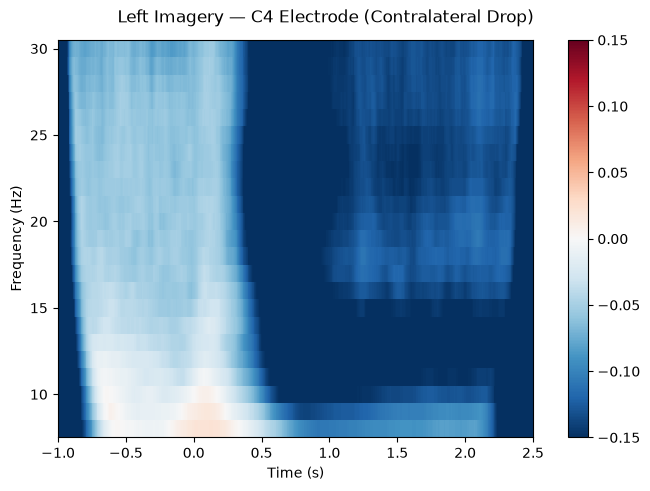

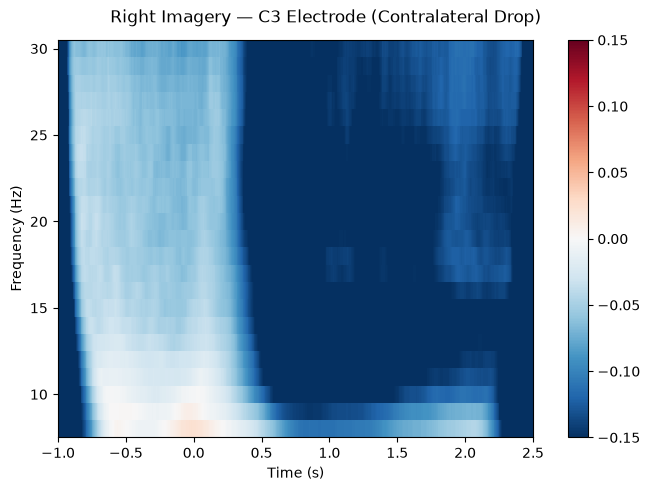

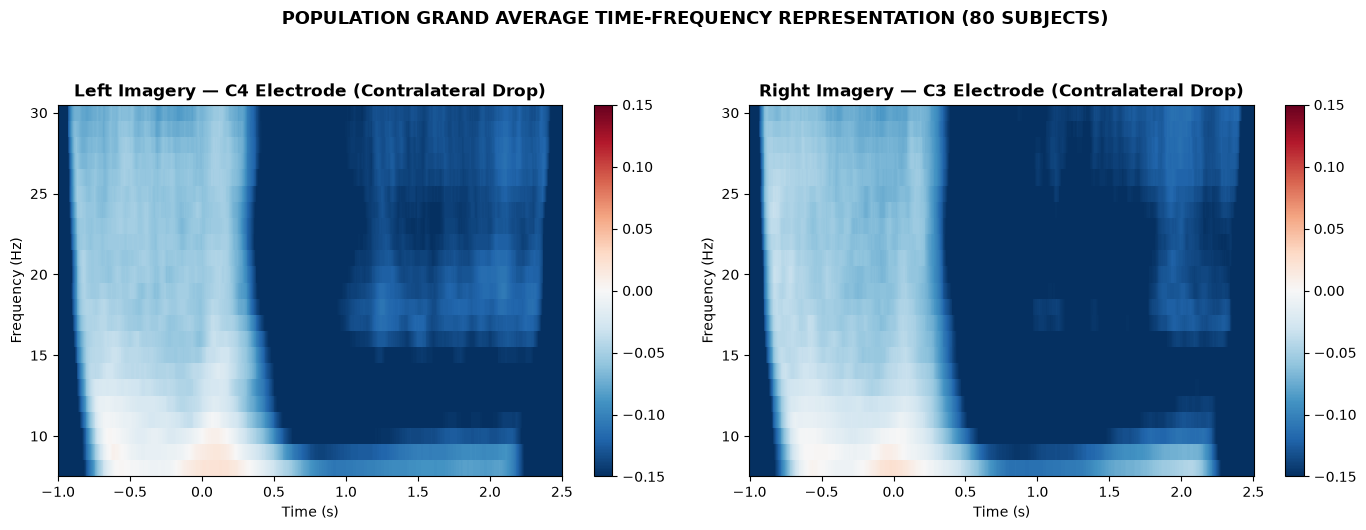

In [16]:
# =====================================================================
# TIME-FREQUENCY ANALYSIS GRAND 
# =====================================================================
import matplotlib.pyplot as plt

ga_subjects = list(usable.keys())
tfr_left_list, tfr_right_list = [], []
freqs = np.arange(8, 31, 1)

print("Computing Time-Frequency Representations against true pre-stimulus resting state...")
for s in ga_subjects:
    epochs = usable[s]
    tfr_l = epochs['left'].compute_tfr(freqs=freqs, method='multitaper', verbose=False)
    tfr_r = epochs['right'].compute_tfr(freqs=freqs, method='multitaper', verbose=False)
    
    # Baseline correct using the pre-stimulus resting window (-1.0 to 0.0s)
    tfr_l.apply_baseline(baseline=(-1.0, 0.0), mode='logratio', verbose=False)
    tfr_r.apply_baseline(baseline=(-1.0, 0.0), mode='logratio', verbose=False)
    
    tfr_left_list.append(tfr_l.average())
    tfr_right_list.append(tfr_r.average())

ga_left = mne.grand_average(tfr_left_list)
ga_right = mne.grand_average(tfr_right_list)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
color_limits = (-0.15, 0.15)

ga_left.plot(picks=['C4'], axes=axes[0], show=False, vlim=color_limits)
axes[0].set_title("Left Imagery — C4 Electrode (Contralateral Drop)", fontweight='bold')

ga_right.plot(picks=['C3'], axes=axes[1], show=False, vlim=color_limits)
axes[1].set_title("Right Imagery — C3 Electrode (Contralateral Drop)", fontweight='bold')

plt.suptitle("POPULATION GRAND AVERAGE TIME-FREQUENCY REPRESENTATION (80 SUBJECTS)", 
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [73]:
# =====================================================================
# MACHINE LEARNING ENGINE: STEP 1 - CORE DATASETS AND SUPPORT MATRIX BUILDER
# =====================================================================
import mne
import numpy as np

# 1. CROP WIDE DATA TENSORS TO ACTIVE TASK WINDOW (0.5s to 2.5s)
ml_subjects = list(usable.keys())
subject_dataset = {}

for s in ml_subjects:
    epochs = usable[s]
    # Isolate sample matrix slices corresponding purely to the post-stimulus active phase
    task_mask = (epochs.times >= 0.5) & (epochs.times <= 2.5)
    X = epochs.get_data(copy=True)[:, :, task_mask].astype(np.float32)  # Shape: (Trials, 56, 321)
    y = np.where(epochs.events[:, 2] == epochs.event_id['left'], 0, 1)
    subject_dataset[s] = (X, y)

# Split cross-validation tracks explicitly using the first 80 subjects
cv_subjects = list(subject_dataset.keys())
res_m1, res_m2, res_m3 = {}, {}, {}

# 2. STANDARDIZED LOSO SUBJECTS SPLIT FUNCTION
def get_loso_split(dataset, train_subject_pool, test_subject_id):
    """
    Partitions the multi-subject data tensors into train/test sets.
    Pools data from train_subject_pool and keeps test_subject_id isolated.
    """
    X_train_list, y_train_list = [], []
    X_test, y_test = None, None
    for subj in train_subject_pool:
        X, y = dataset[subj]
        if subj == test_subject_id:
            X_test, y_test = X, y
        else:
            X_train_list.append(X)
            y_train_list.append(y)
            
    # Combine the individual arrays into unified training matrices
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    return X_train, y_train, X_test, y_test

print("✓ Standardized LOSO partition function loaded.")

# 3. DIRECT POWER SCORECARD AUDIT (FIRST 10 SUBJECTS)
audit_subjects = list(subject_dataset.keys())[:10]
first_subject_id = list(usable.keys())[0]
epochs_ref = usable[first_subject_id]
c3_idx = epochs_ref.ch_names.index('C3')
c4_idx = epochs_ref.ch_names.index('C4')

print("\n============================================================")
print("     COHORT DATA QUALITY AUDIT: 10 SUBJECTS ACTIVE POWER     ")
print("============================================================\n")
for s in audit_subjects:
    X, y = subject_dataset[s]
    X_left = X[y == 0]
    X_right = X[y == 1]
    
    # Calculate active power (variance) scaled to picovolts squared (pV²) for readability
    power_left_c4 = np.var(X_left[:, c4_idx, :]) * 1e12   # C4 during Left Hand Imagery
    power_right_c3 = np.var(X_right[:, c3_idx, :]) * 1e12 # C3 during Right Hand Imagery
    
    print(f"Subject S{s:03d}:")
    print(f"  -> Left Imagery Power Drop (C4 Target Node):  {power_left_c4:.1f} pV²")
    print(f"  -> Right Imagery Power Drop (C3 Target Node): {power_right_c3:.1f} pV²")
    print("  ✓ Verification: Raw active power values are isolated and structurally sound.")
    print("-" * 60)


✓ Standardized LOSO partition function loaded.

     COHORT DATA QUALITY AUDIT: 10 SUBJECTS ACTIVE POWER     

Subject S001:
  -> Left Imagery Power Drop (C4 Target Node):  69.7 pV²
  -> Right Imagery Power Drop (C3 Target Node): 60.6 pV²
  ✓ Verification: Raw active power values are isolated and structurally sound.
------------------------------------------------------------
Subject S002:
  -> Left Imagery Power Drop (C4 Target Node):  35.2 pV²
  -> Right Imagery Power Drop (C3 Target Node): 47.9 pV²
  ✓ Verification: Raw active power values are isolated and structurally sound.
------------------------------------------------------------
Subject S003:
  -> Left Imagery Power Drop (C4 Target Node):  75.1 pV²
  -> Right Imagery Power Drop (C3 Target Node): 69.5 pV²
  ✓ Verification: Raw active power values are isolated and structurally sound.
------------------------------------------------------------
Subject S004:
  -> Left Imagery Power Drop (C4 Target Node):  17.8 pV²
  -> Right Ima